**Olist Visualization Dashboard**

In [2]:
# Project : Olist Visualization Dashboard
# Aim : creating an insight-driven visualization dashboard for the Olist e-commerce data

# Tasks/visuals to include:
# revenue over time
# top product categories
# price distribution
# correlation b/w price and freight value of products
# category vs price value

# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading all required Olist datasets
orders = pd.read_csv("olist_orders_dataset.csv")  # contains orders data
orders_items = pd.read_csv("olist_order_items_dataset.csv")  # contains data of items present in orders
products = pd.read_csv("olist_products_dataset.csv")  # contains information of products listed on the store
products_translated = pd.read_csv("product_category_name_translation.csv")  # contains english-translated names of products (initially brazillian)

# print(orders.head())
# print(orders_items.head())
# print(products.head())
# print(products_translated.head())

# print(orders["order_status"].unique())
# keeping only relevant columns from the datasets
orders = orders.loc[orders["order_status"]=="delivered",["order_id","order_purchase_timestamp"]]
print(orders.head())

orders_items = orders_items.loc[:,["order_id","product_id","price","freight_value"]]
print(orders_items.head())

products = products.loc[:,["product_id","product_category_name"]]
print(products.head())

print(products_translated.head())

                           order_id order_purchase_timestamp
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39
                           order_id                        product_id   price  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   58.90   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f  239.90   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd  199.00   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089  199.90   

   freight_value  
0          13.29  
1          19.93  
2          17.87  
3          12.79  
4          18.14  
                         product_

In [3]:
# print(products.columns)
# print(products_translated.columns)

# combining products and products_translated datasets to directly have the translated names of the products
products_df = pd.merge(products, products_translated, on="product_category_name", how="inner")
products_df.drop("product_category_name", axis=1, inplace=True)
products_df.rename(columns={"product_category_name_english":"product_category"}, inplace=True)
print(products_df.head())

                         product_id product_category
0  1e9e8ef04dbcff4541ed26657ea517e5        perfumery
1  3aa071139cb16b67ca9e5dea641aaa2f              art
2  96bd76ec8810374ed1b65e291975717f   sports_leisure
3  cef67bcfe19066a932b7673e239eb23d             baby
4  9dc1a7de274444849c219cff195d0b71       housewares


In [4]:
# combining order_items data with the products based on the product_id
orders_items_df = pd.merge(orders_items, products_df, on="product_id", how="inner")
print(orders_items_df.head())

                           order_id                        product_id   price  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   58.90   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f  239.90   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd  199.00   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089  199.90   

   freight_value product_category  
0          13.29       cool_stuff  
1          19.93         pet_shop  
2          17.87  furniture_decor  
3          12.79        perfumery  
4          18.14     garden_tools  


In [5]:
# combining dataset with all orders information with the order_items obtained dataset using order_id as the key
orders_df = pd.merge(orders, orders_items_df, on="order_id", how="inner")
orders_df.drop("product_id", axis=1, inplace=True)
print(orders_df.head())

                           order_id order_purchase_timestamp   price  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   29.99   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37  118.70   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49  159.90   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   45.00   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   19.90   

   freight_value product_category  
0           8.72       housewares  
1          22.76        perfumery  
2          19.22             auto  
3          27.20         pet_shop  
4           8.72       stationery  


In [6]:
# calculating total value of orders by adding price with the respective freight values
orders_df["total_value"] = orders_df["price"] + orders_df["freight_value"]
print(orders_df.head())

                           order_id order_purchase_timestamp   price  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   29.99   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37  118.70   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49  159.90   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   45.00   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   19.90   

   freight_value product_category  total_value  
0           8.72       housewares        38.71  
1          22.76        perfumery       141.46  
2          19.22             auto       179.12  
3          27.20         pet_shop        72.20  
4           8.72       stationery        28.62  


Revenue (total_value of orders) over time

In [9]:
# printing unique order years
print(orders_df["order_purchase_timestamp"].str[:4].unique())

['2017' '2018' '2016']


In [13]:
# getting years of orders as a separate column in the dataframe
orders_df["order_year"] = orders_df["order_purchase_timestamp"].str[:4]
print(orders_df.head())

                           order_id order_purchase_timestamp   price  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   29.99   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37  118.70   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49  159.90   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   45.00   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   19.90   

   freight_value product_category  total_value order_year  
0           8.72       housewares        38.71       2017  
1          22.76        perfumery       141.46       2018  
2          19.22             auto       179.12       2018  
3          27.20         pet_shop        72.20       2017  
4           8.72       stationery        28.62       2018  


In [15]:
# getting total orders per year
orders_per_year = orders_df.groupby("order_year")["total_value"].sum()
print(orders_per_year)

order_year
2016      46557.82
2017    6805543.54
2018    8364318.55
Name: total_value, dtype: float64


Text(0.5, 1.0, 'Total Orders Values per Year')

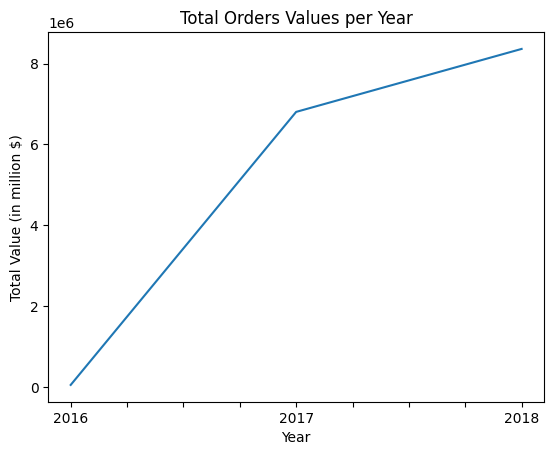

In [33]:
# creating a line plot of total order value per year
fig = plt.figure()
ax = fig.add_subplot()

# ax.plot(orders_df["order_purchase_timestamp"].str[:4], orders_df["freight_value"])
# ax.plot(orders_df["order_year"], orders_df["freight_value"])
orders_per_year.plot(ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Total Value (in million $)")
ax.set_title("Total Orders Values per Year")

order_year
2016    147.802603
2017    139.810250
2018    140.232682
Name: total_value, dtype: float64


Text(0.5, 1.0, 'Average Order Values per Year')

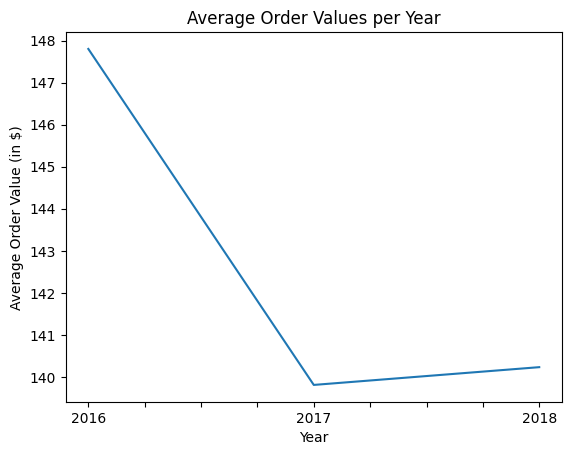

In [34]:
# getting mean order value per year
avg_orders_per_year = orders_df.groupby("order_year")["total_value"].mean()
print(avg_orders_per_year)

# creating a line plot for average order value per year
fig = plt.figure()
ax = fig.add_subplot()

avg_orders_per_year.plot(ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Average Order Value (in $)")
ax.set_title("Average Order Values per Year")

Top categories

In [21]:
print(orders_df.head())

                           order_id order_purchase_timestamp   price  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   29.99   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37  118.70   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49  159.90   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   45.00   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   19.90   

   freight_value product_category  total_value order_year  
0           8.72       housewares        38.71       2017  
1          22.76        perfumery       141.46       2018  
2          19.22             auto       179.12       2018  
3          27.20         pet_shop        72.20       2017  
4           8.72       stationery        28.62       2018  


In [25]:
# ranking categories on the basis of most total order value
# calculating total order value for every product category

print(orders_df["product_category"].unique()[:5])
print(len(orders_df["product_category"].unique()))

['housewares' 'perfumery' 'auto' 'pet_shop' 'stationery']
71


In [43]:
categories_total_value = orders_df.groupby("product_category")["total_value"].sum().reset_index()
print(categories_total_value)

              product_category  total_value
0   agro_industry_and_commerce     76203.30
1             air_conditioning     59854.55
2                          art     27485.53
3        arts_and_craftmanship      2184.14
4                        audio     56255.32
..                         ...          ...
66                  stationery    269575.05
67      tablets_printing_image      8754.61
68                   telephony    379202.62
69                        toys    547061.06
70               watches_gifts   1264333.12

[71 rows x 2 columns]


In [44]:
# ranking categories on the basis of their total order values
categories_total_value["product_rank"] = categories_total_value["total_value"].rank(method="dense", ascending=False)
categories_total_value.sort_values(by="product_rank", inplace=True)

print(categories_total_value)

             product_category  total_value  product_rank
43              health_beauty   1412089.53           1.0
70              watches_gifts   1264333.12           2.0
7              bed_bath_table   1225209.26           3.0
65             sports_leisure   1118256.91           4.0
15      computers_accessories   1032723.77           5.0
..                        ...          ...           ...
35                    flowers      1598.91          67.0
46             home_comfort_2      1170.58          68.0
11          cds_dvds_musicals       954.99          69.0
29  fashion_childrens_clothes       598.67          70.0
61      security_and_services       324.51          71.0

[71 rows x 3 columns]


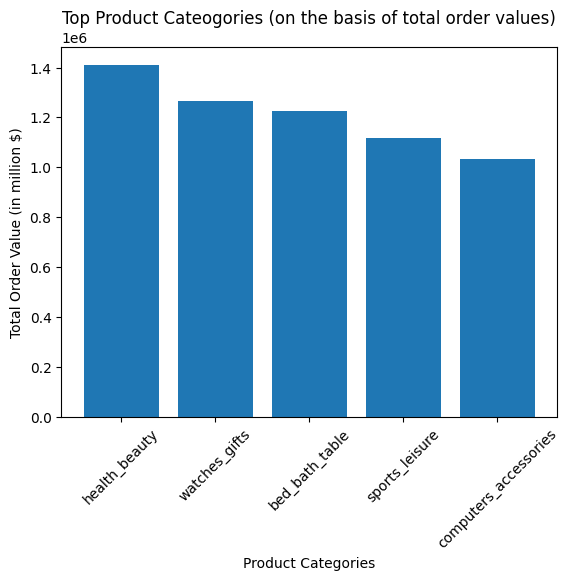

In [48]:
# creating a bar plot to represent the top categories according to their total order values
fig = plt.figure()
ax = fig.add_subplot()

top_categories = categories_total_value[:5]

ax.bar(top_categories["product_category"], top_categories["total_value"])
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("Product Categories")
ax.set_ylabel("Total Order Value (in million $)")
ax.set_title("Top Product Cateogories (on the basis of total order values)");

Price distribution of orders

(array([77397., 21336.,  4874.,  1680.,  1142.,   580.,   421.,   295.,
          187.,   196.]),
 array([   0.,  120.,  240.,  360.,  480.,  600.,  720.,  840.,  960.,
        1080., 1200.]),
 <BarContainer object of 10 artists>)

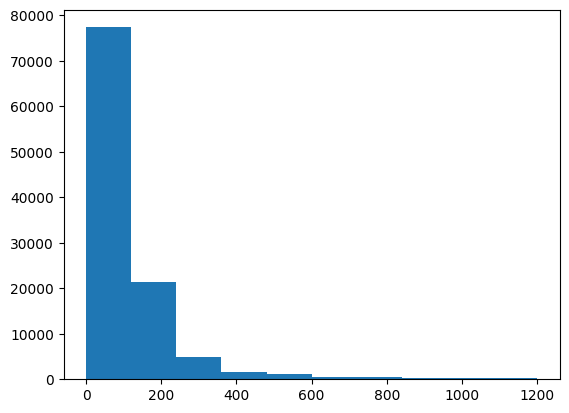

In [56]:
# creating a histogram to depict price distribution of orders
fig = plt.figure()
ax = fig.add_subplot()

ax.hist(orders_df["price"], range=(0,1200), bins=10)

[77397. 21336.  4874.  1680.  1142.   580.   421.   295.   187.   196.]
[   0.  120.  240.  360.  480.  600.  720.  840.  960. 1080. 1200.]
<BarContainer object of 10 artists>
price-wise counts of orders (bin-wise counts of histogram):
(0.0 $ , 120.0 $]: 77397.0
(120.0 $ , 240.0 $]: 21336.0
(240.0 $ , 360.0 $]: 4874.0
(360.0 $ , 480.0 $]: 1680.0
(480.0 $ , 600.0 $]: 1142.0
(600.0 $ , 720.0 $]: 580.0
(720.0 $ , 840.0 $]: 421.0
(840.0 $ , 960.0 $]: 295.0
(960.0 $ , 1080.0 $]: 187.0
(1080.0 $ , 1200.0 $]: 196.0


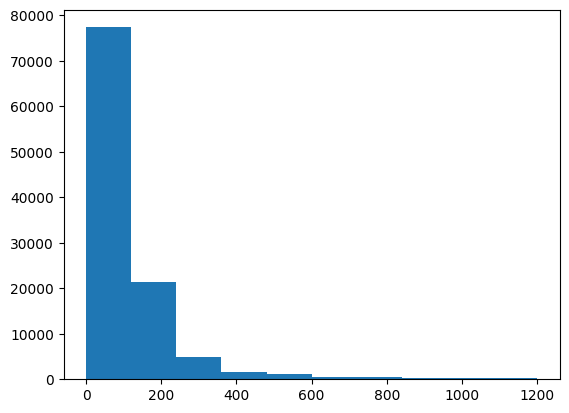

In [60]:
# printing price range wise counts using the same histogram
counts, bins, patches = plt.hist(orders_df["price"], range=(0,1200), bins=10)
print(counts)
print(bins)
print(patches)

print("price-wise counts of orders (bin-wise counts of histogram):")
for idx in range(len(counts)):
  print(f"({bins[idx]} $ , {bins[idx+1]} $]:", counts[idx])

{'whiskers': [<matplotlib.lines.Line2D at 0x7e226189aab0>,
 'caps': [<matplotlib.lines.Line2D at 0x7e226189b0e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e22618b2cc0>,
 'medians': [<matplotlib.lines.Line2D at 0x7e226189b800>,
 'fliers': [<matplotlib.lines.Line2D at 0x7e226189bb30>,
 'means': []}

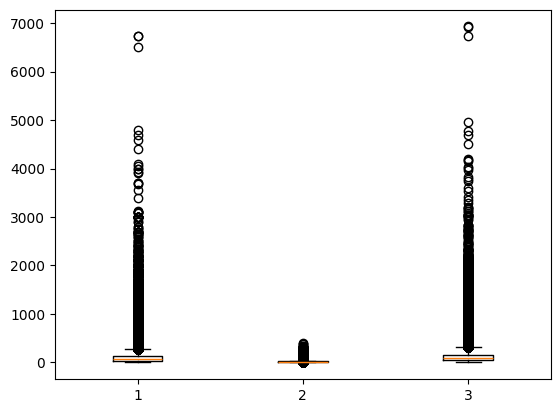

In [100]:
# creating a box plot (box and whiskers plot) for price, freight value and total order values to inspect their respective distributions and also check upon any outliers if present visually
fig = plt.figure()
ax = fig.add_subplot()

ax.boxplot(orders_df[["price", "freight_value", "total_value"]])

Correlation b/w price and total value of products

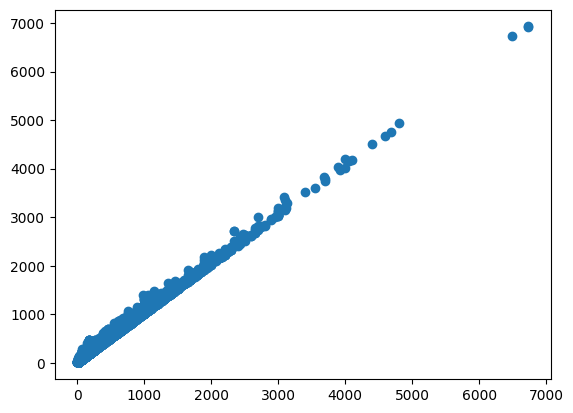

In [63]:
# plotting a scatter plot b/w price and total value
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(orders_df["price"],orders_df["total_value"])

<Axes: xlabel='price', ylabel='total_value'>

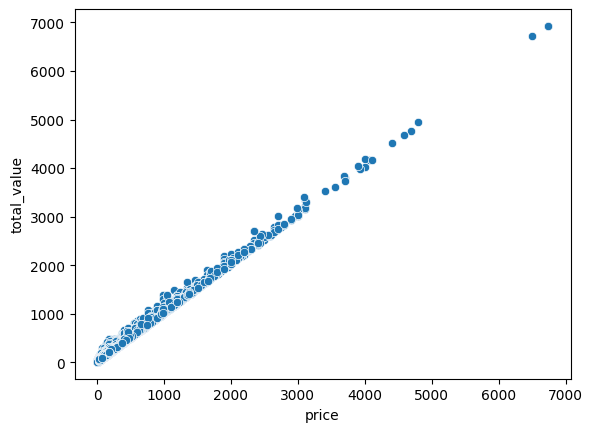

In [68]:
# plotting the same scatter plot using seaborn
sns.scatterplot(x=orders_df["price"],y=orders_df["total_value"])

<Axes: xlabel='price', ylabel='total_value'>

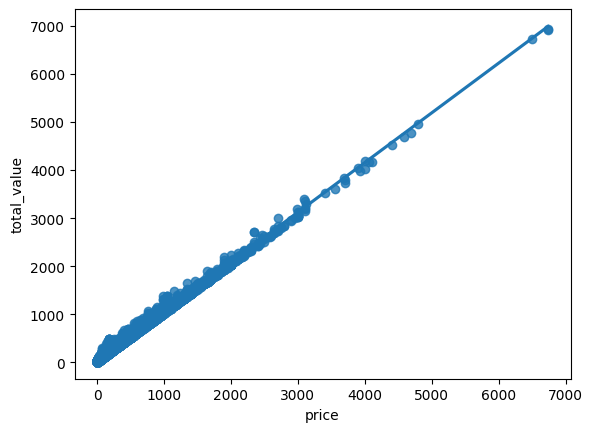

In [69]:
# creating a regression plot b/w price and total value
sns.regplot(x=orders_df["price"], y=orders_df["total_value"])

Category vs price plot

In [76]:
# calculating product category wise mean price and total order values
category_prices = orders_df.groupby("product_category")[["price","total_value"]].agg({"price":"mean", "total_value":"sum"})
print(category_prices)

                                 price  total_value
product_category                                   
agro_industry_and_commerce  342.553883     76203.30
air_conditioning            184.510588     59854.55
art                         120.087817     27485.53
arts_and_craftmanship        75.583750      2184.14
audio                       139.697790     56255.32
...                                ...          ...
stationery                   90.749672    269575.05
tablets_printing_image       90.703735      8754.61
telephony                    69.945876    379202.62
toys                        116.944536    547061.06
watches_gifts               199.040276   1264333.12

[71 rows x 2 columns]


In [79]:
# normalizing values in category_prices df
category_prices_norm = (category_prices - category_prices.min()) / (category_prices.max() - category_prices.min())
print(category_prices_norm)

                               price  total_value
product_category                                 
agro_industry_and_commerce  0.295473     0.053747
air_conditioning            0.148260     0.042167
art                         0.088252     0.019239
arts_and_craftmanship       0.046798     0.001317
audio                       0.106519     0.039618
...                              ...          ...
stationery                  0.060925     0.190719
tablets_printing_image      0.060882     0.005971
telephony                   0.041547     0.268372
toys                        0.085325     0.387272
watches_gifts               0.161794     0.895339

[71 rows x 2 columns]


<Axes: ylabel='product_category'>

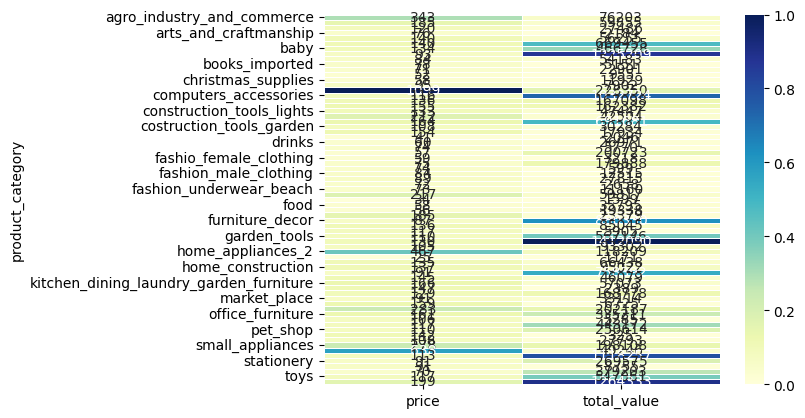

In [81]:
# creating a heatmap of product category wise prices and total value with color bars according to the normalized values and original values written over the plot
sns.heatmap(category_prices_norm, annot=category_prices, fmt=".0f", cmap="YlGnBu", linewidths=.5)

<Axes: ylabel='product_category'>

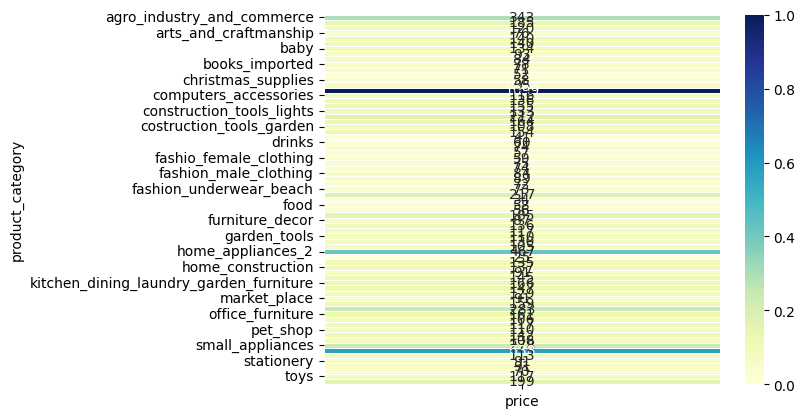

In [85]:
# creating a heatmap for price values of product categories
sns.heatmap(category_prices_norm[["price"]], annot=category_prices[["price"]], fmt=".0f", cmap="YlGnBu", linewidths=.5)

In [90]:
# ranking top 10 product categories according to their price and filtering them out of the whole dataframe
category_prices_norm["rank"] = category_prices_norm["price"].rank(method="dense", ascending=False)
category_prices_norm.sort_values(by="rank", inplace=True)
category_prices_norm = category_prices_norm[:10]
print(category_prices_norm)

                                          price  total_value  rank
product_category                                                  
computers                              1.000000     0.161518   1.0
small_appliances_home_oven_and_coffee  0.570870     0.034653   2.0
home_appliances_2                      0.411701     0.083501   3.0
agro_industry_and_commerce             0.295473     0.053747   4.0
musical_instruments                    0.240119     0.142986   5.0
small_appliances                       0.235102     0.140097   6.0
fixed_telephony                        0.178451     0.042140   7.0
construction_tools_safety              0.173750     0.029877   8.0
watches_gifts                          0.161794     0.895339   9.0
furniture_bedroom                      0.148687     0.016330  10.0


In [94]:
# the same procedure of ranking and filtering top 10 product categories based on the price values on the initial non-normalized dataframe for efficient mapping while calling the heatmap function in seaborn
category_prices = orders_df.groupby("product_category")[["price","total_value"]].agg({"price":"mean", "total_value":"sum"})
category_prices["rank"] = category_prices["price"].rank(method="dense", ascending=False)
category_prices.sort_values(by="rank", inplace=True)
category_prices = category_prices[:10]
print(category_prices)

                                             price  total_value  rank
product_category                                                     
computers                              1098.915276    228349.76   1.0
small_appliances_home_oven_and_coffee   638.213151     49245.90   2.0
home_appliances_2                       467.333117    118208.52   3.0
agro_industry_and_commerce              342.553883     76203.30   4.0
musical_instruments                     283.127097    202187.12   5.0
small_appliances                        277.741824    198108.47   6.0
fixed_telephony                         216.922392     59816.54   7.0
construction_tools_safety               211.875519     42504.02   8.0
watches_gifts                           199.040276   1264333.12   9.0
furniture_bedroom                       184.968932     23379.22  10.0


<Axes: ylabel='product_category'>

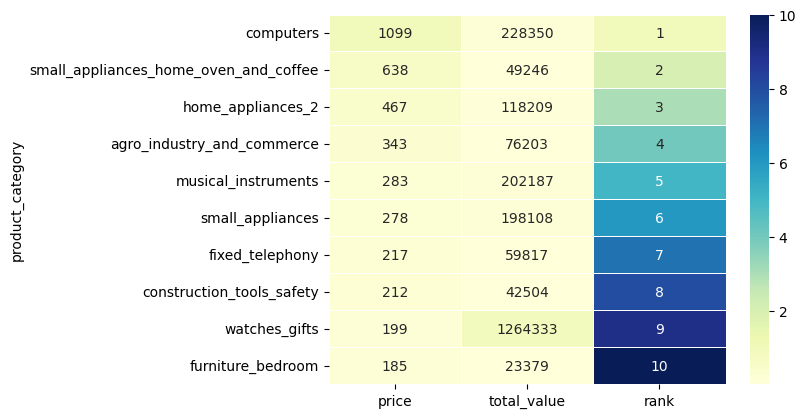

In [96]:
# creating a heatmap of top 10 categories based on their prices (all dataframe columns)
sns.heatmap(category_prices_norm, annot=category_prices, fmt=".0f", cmap="YlGnBu", linewidths=.5)

<Axes: ylabel='product_category'>

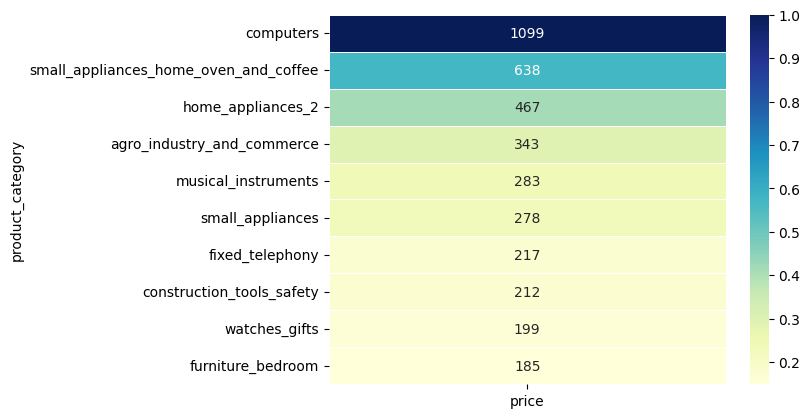

In [97]:
# creating a heatmap of top 10 categories based on their prices (only the price column)
sns.heatmap(category_prices_norm[["price"]], annot=category_prices[["price"]], fmt=".0f", cmap="YlGnBu", linewidths=.5)